# Part 3: Filtering and the marginal log-likelihood

This notebook is part of the [Gentle Introduction to Dynestyx](00_index.ipynb). We use **filtering** (e.g. the cuthbert particle filter) to compute the **marginal log-likelihood** (MLL) $\log p(y_{1:T} \mid \theta)$ at fixed parameters $\theta$, and show how to switch to a different filter (e.g. Taylor KF).

## 3.1 Why filtering? Computing MLL without sampling states

Dynamical systems are a special problem in that they carry lots of structure that we can exploit in inference --- in the types of dynamical systems specified in dynestyx, observations depend only on the state (and possibly observed control inputs), and the next state depends only on the current state (and possibly observed control inputs). This suggests a family of algorithms that exploit this structure, using only the relevant information when inferring a particular state.

Additionally, sometimes we don't want to infer the full state trajectory anyways -- we only care about **parameters** $\theta$ that describe the system. The resulting problem is called **system identification**, and only necessitates the **marginal likelihood** $\log p(y_{1:T} \mid \theta)$, which implicitly marginalizes the states. 

Mathematically, both of these goals are accomplished by a **filtering** algorithm; filtering algorithms exploit the structure of a dynamical system for efficient estimation, whilst also providing an estimate of the marginal likelihood. Dynestyx provides a set of filtering handlers that add this marginal likelihood as a NumPyro factor, so we can evaluate $\log p(\text{data} \mid \theta)$ at any $\theta$.

We'll use the **particle filter** (from the library [`cuthbert`](https://www.github.com/state-space-models/cuthbert)) to compute a "profile likelihood": that is, we will plot the marginal log-likelihood (MLL) vs $\theta$.

We evaluate the model at fixed parameters (as when using `Predictive` with `params=...`) and read the MLL factor from the trace.

### Define the model

Our model definition is the same as in the previous tutorial, providing a linear Gaussian system.

In [1]:
import jax.numpy as jnp
import jax.random as jr
import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import (
    Condition,
    Context,
    DiscreteTimeSimulator,
    DynamicalModel,
    Trajectory,
)

# for convenience, we can define "fixed" things in the model outside of it.
# this is not required, but it helps keep the model clean.
state_dim = 2
observation_dim = 1
control_dim = 1

# Create the known matrices B, C
B = jnp.eye(state_dim, control_dim)
C = jnp.eye(observation_dim, state_dim)

# create the initial condition as a distribution
initial_condition = dist.MultivariateNormal(jnp.zeros(state_dim), jnp.eye(state_dim))


def lti_model(sigma_obs=0.1, sigma_process=0.1):
    # sample the unknown parameter
    rho = numpyro.sample("rho", dist.Uniform(-0.5, 0.5))
    A = jnp.array([[0, 0.3], [rho, -0.2]])

    # create the state evolution as a callable mapping to a distribution
    # Crucially, this depends on A, which depends on rho, which is unknown.
    # Thus, the state evolution MUST be defined within `lti_model`, not outside.
    state_evolution = lambda x, u, t_now, t_next: dist.MultivariateNormal(
        A @ x + B @ u, sigma_process**2 * jnp.eye(state_dim)
    )

    # create the observation model as a callable mapping to a distribution
    observation_model = lambda x, u, t: dist.MultivariateNormal(
        C @ x, sigma_obs**2 * jnp.eye(observation_dim)
    )

    # create the dynamical model
    dynamics = DynamicalModel(
        state_dim=state_dim,
        observation_dim=observation_dim,
        control_dim=control_dim,
        initial_condition=initial_condition,
        state_evolution=state_evolution,
        observation_model=observation_model,
    )

    # sample from the dynamical model
    dsx.sample("f", dynamics)

### Generate synthetic data with $\rho = 0.3$.

Next, we generate synthetic data using a true value of $\rho = 0.3$.

In [2]:
# create a synthetic control sequence as i.i.d. Gaussians
obs_times = jnp.arange(0.0, 100.0, 1.0)  # T=100 steps
ctrl_times = obs_times  # same times for controls
ctrl_values = jr.normal(jr.PRNGKey(0), (len(ctrl_times), control_dim))
sim_context = Context(
    observations=Trajectory(times=obs_times),
    controls=Trajectory(times=obs_times, values=ctrl_values),
)

rho_true = 0.3


def make_data(sigma_obs=0.1, sigma_process=0.1):
    # create a time-conditioned model for data generation
    def time_conditioned_model():
        with DiscreteTimeSimulator():
            with Condition(sim_context):
                return lti_model(sigma_obs=sigma_obs, sigma_process=sigma_process)

    predictive = Predictive(
        time_conditioned_model,
        params={"rho": jnp.array(rho_true)},
        num_samples=1,
        exclude_deterministic=False,
    )
    pred = predictive(rng_key=jr.PRNGKey(0))
    # synthetic data object
    observed_context = Context(
        observations=Trajectory(times=obs_times, values=pred["observations"][0]),
        controls=Trajectory(times=obs_times, values=ctrl_values),
    )

    return observed_context


observed_context = make_data(sigma_obs=0.1, sigma_process=0.1)

### Build the data-conditioned filter-marginalized model

To condition a model using a filtering algorithm, we use a `FilterBasedMarginalLikelihood` object. This takes in a `FilterConfig` which can be imported from `dynestyx.filters`; each  outlines a different set of exact or approximate algorithms for filtering. For now, we will use a particle filter, and a Taylor-extended Kalman filter. The former is expensive but exact for a wide range of problems, while the latter is cheaper, and --- in the case of linear Gaussian state space models --- optimal.

We'll now build a function that returns the MLL at a particular value of the parameter $\rho$, conditioned on data, and plot the resulting *likelihood profile*.

In [3]:
from dynestyx import FilterBasedMarginalLogLikelihood
from dynestyx.filters import EKFConfig, PFConfig

def get_mll(rho, filter_config):
    """Evaluate model at fixed params via Predictive and return the MLL (deterministic site)."""

    with FilterBasedMarginalLogLikelihood(filter_config):
        with Condition(observed_context):
            predictive = Predictive(
                lti_model,
                params={"rho": rho},
                num_samples=1,
                exclude_deterministic=False,
            )
            mll = predictive(jr.PRNGKey(0))["f_marginal_loglik"]

    return mll


get_mll(0.3, EKFConfig())

Array([30.354883], dtype=float32)

Since dynestyx and its dependencies are written in `jax`, we can exploit its tools for efficient inference (such as jit-compiling or vectorization). In this case, we will generate the likelihood profiles by vmapping over different values of $\rho$.

In [4]:
from jax import vmap

# Profile over values of rho, keeping other parameters at their true values:
rho_grid = jnp.linspace(-0.8, 0.8, 50)

mll_kf = vmap(lambda p: get_mll(p, filter_config=EKFConfig()))(rho_grid)
mll_pf = vmap(lambda p: get_mll(p, filter_config=PFConfig()))(rho_grid)

We now plot the likelihood profiles, which should be at a maximum at or near the true data-generating value $\rho = 0.3$.

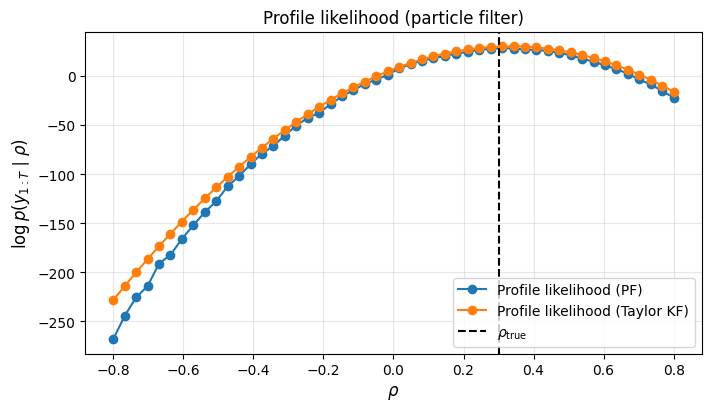

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(rho_grid, mll_pf, "o-", color="C0", label="Profile likelihood (PF)")
ax.plot(rho_grid, mll_kf, "o-", color="C1", label="Profile likelihood (Taylor KF)")
ax.axvline(rho_true, color="k", linestyle="--", label=r"$\rho_{\mathrm{true}}$")
ax.set_xlabel(r"$\rho$", fontsize=12)
ax.set_ylabel(r"$\log p(y_{1:T} \mid \rho)$", fontsize=12)
ax.set_title("Profile likelihood (particle filter)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

We additionally note that for non-Bayesian analysis --- for example, obtaining a maximum likelihood estimate of the system's parameters --- you can consider the filter-based MLL as a "loss function" and proceed from there with learning dynamical systems from data. 

We can also use these likelihood approximations inside other Bayesian inference methods to do posterior inference over unknown parameters, which we explore in the next tutorial.

**Next:** [Part 4 — Filtering + NUTS: pseudomarginal inference](../04_filtering_nuts_pseudomarginal.ipynb)